# 04: Explainability and Visualization

This notebook generates explanations for model predictions and visualizes important molecular substructures.

## Objectives

1. Load trained models (Baseline MLP, BFGNN, GRIN, SMILESTransformer)
2. Generate attributions for predictions using appropriate methods
3. Visualize molecules with importance highlighting
4. Analyze substructures associated with toxicity
5. Compare explanations across different model architectures



In [1]:
# Setup
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

project_root = Path().absolute().parent
sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

from src.pipelines import (
    load_clintox_dataset,
    load_mlp_model,
    load_gnn_model,
    evaluate_mlp_pipeline
)
from src.featurization import featurize_batch
from src.explain import explain_molecule, explain_torch_molecule_model
from src.viz import plot_explained_molecule, plot_explained_grid, map_fingerprint_to_atoms
from src.train import predict_with_torch_molecule_model
from src.utils import set_seed, get_default_config

# Set seed
set_seed(42)
config = get_default_config()

print("✓ Imports successful")



✓ Imports successful


## Load Data and Models

Load the test dataset and all trained models (Baseline MLP, BFGNN, GRIN, and SMILESTransformer).



In [2]:
# Load dataset using pipeline function
train_df, val_df, test_df = load_clintox_dataset(
    cache_dir=str(project_root / "data"),
    split_type="scaffold",
    seed=42
)

print(f"Test set size: {len(test_df)}")

# Load models using pipeline functions
models_dir = project_root / "models"
mlp_model = None
bfgnn_model = None
grin_model = None
smilestransformer_model = None

# Load Baseline MLP model
mlp_model_path = models_dir / "baseline_mlp_model.pt"
if mlp_model_path.exists():
    mlp_model = load_mlp_model(mlp_model_path, config)
    print("✓ Baseline MLP model loaded")
    print("  Model type: Fingerprint-based MLP")
    print("  Attribution method: Gradient-based (fingerprint level)")
else:
    print("⚠ Baseline MLP model not found. Train it in notebook 02.")

# Load BFGNN model
bfgnn_model_path = models_dir / "torch_molecule_model.pkl"
if not bfgnn_model_path.exists():
    bfgnn_model_path = models_dir / "torch_molecule_model.pt"
if bfgnn_model_path.exists():
    try:
        bfgnn_model = load_gnn_model(bfgnn_model_path)
        print("✓ BFGNN model loaded")
        print("  Model type: torch-molecule BFGNN")
        print("  Attribution method: Perturbation-based (atom removal)")
    except Exception as e:
        print(f"⚠ Could not load BFGNN model: {e}")
else:
    print("⚠ BFGNN model not found. Train it in notebook 03_training_gnn.ipynb.")

# Load GRIN model
grin_model_path = models_dir / "grin_model.pkl"
if not grin_model_path.exists():
    grin_model_path = models_dir / "grin_model.pt"
if grin_model_path.exists():
    try:
        grin_model = load_gnn_model(grin_model_path)
        print("✓ GRIN model loaded")
        print("  Model type: torch-molecule GRIN")
        print("  Attribution method: Perturbation-based (atom removal)")
    except Exception as e:
        print(f"⚠ Could not load GRIN model: {e}")
else:
    print("⚠ GRIN model not found. Train it in notebook 03_training_grin.ipynb.")

# Load SMILESTransformer model
smilestransformer_model_path = models_dir / "smilestransformer_model.pkl"
if not smilestransformer_model_path.exists():
    smilestransformer_model_path = models_dir / "smilestransformer_model.pt"
if smilestransformer_model_path.exists():
    try:
        smilestransformer_model = load_gnn_model(smilestransformer_model_path)
        print("✓ SMILESTransformer model loaded")
        print("  Model type: torch-molecule SMILESTransformer")
        print("  Attribution method: Perturbation-based (atom removal)")
    except Exception as e:
        print(f"⚠ Could not load SMILESTransformer model: {e}")
else:
    print("⚠ SMILESTransformer model not found. Train it in notebook 03_training_smilestransformer.ipynb.")



No normalization for SPS. Feature removed!
No normalization for AvgIpc. Feature removed!
Skipped loading some Tensorflow models, missing a dependency. No module named 'tensorflow'
Skipped loading modules with pytorch-geometric dependency, missing a dependency. No module named 'dgl'
Skipped loading modules with pytorch-lightning dependency, missing a dependency. No module named 'lightning'
Skipped loading some Jax models, missing a dependency. No module named 'jax'
Skipped loading some PyTorch models, missing a dependency. No module named 'tensorflow'


Test set size: 148
✓ Baseline MLP model loaded
  Model type: Fingerprint-based MLP
  Attribution method: Gradient-based (fingerprint level)
✓ BFGNN model loaded
  Model type: torch-molecule BFGNN
  Attribution method: Perturbation-based (atom removal)
✓ GRIN model loaded
  Model type: torch-molecule GRIN
  Attribution method: Perturbation-based (atom removal)
✓ SMILESTransformer model loaded
  Model type: torch-molecule SMILESTransformer
  Attribution method: Perturbation-based (atom removal)


## Generate Predictions

Generate predictions on test set to identify examples for explanation.



In [3]:
# Generate predictions for all available models
test_df = test_df.copy()

# MLP predictions
if mlp_model is not None:
    test_fps = featurize_batch(
        test_df['smiles'].tolist(),
        mode="fingerprint",
        radius=config['featurization']['fingerprint']['radius'],
        n_bits=config['featurization']['fingerprint']['n_bits']
    )
    
    with torch.no_grad():
        test_tensors = torch.FloatTensor(test_fps)
        logits = mlp_model(test_tensors)
        test_df['predicted_prob_mlp'] = torch.sigmoid(logits).numpy().flatten()
        test_df['predicted_label_mlp'] = (test_df['predicted_prob_mlp'] > 0.5).astype(int)
        test_df['correct_mlp'] = (test_df['CT_TOX'] == test_df['predicted_label_mlp'])
    
    print(f"✓ MLP predictions generated")
    print(f"  Accuracy: {test_df['correct_mlp'].mean():.4f}")

# BFGNN predictions
if bfgnn_model is not None:
    test_df['predicted_prob_bfgnn'] = predict_with_torch_molecule_model(
        bfgnn_model, test_df['smiles'].tolist()
    )
    test_df['predicted_label_bfgnn'] = (test_df['predicted_prob_bfgnn'] > 0.5).astype(int)
    test_df['correct_bfgnn'] = (test_df['CT_TOX'] == test_df['predicted_label_bfgnn'])
    
    print(f"✓ BFGNN predictions generated")
    print(f"  Accuracy: {test_df['correct_bfgnn'].mean():.4f}")

# GRIN predictions
if grin_model is not None:
    test_df['predicted_prob_grin'] = predict_with_torch_molecule_model(
        grin_model, test_df['smiles'].tolist()
    )
    test_df['predicted_label_grin'] = (test_df['predicted_prob_grin'] > 0.5).astype(int)
    test_df['correct_grin'] = (test_df['CT_TOX'] == test_df['predicted_label_grin'])
    
    print(f"✓ GRIN predictions generated")
    print(f"  Accuracy: {test_df['correct_grin'].mean():.4f}")

# SMILESTransformer predictions
if smilestransformer_model is not None:
    test_df['predicted_prob_smilestransformer'] = predict_with_torch_molecule_model(
        smilestransformer_model, test_df['smiles'].tolist()
    )
    test_df['predicted_label_smilestransformer'] = (test_df['predicted_prob_smilestransformer'] > 0.5).astype(int)
    test_df['correct_smilestransformer'] = (test_df['CT_TOX'] == test_df['predicted_label_smilestransformer'])
    
    print(f"✓ SMILESTransformer predictions generated")
    print(f"  Accuracy: {test_df['correct_smilestransformer'].mean():.4f}")

# Identify examples for visualization (MLP)
if mlp_model is not None:
    correct_toxic_mlp = test_df[(test_df['CT_TOX'] == 1) & (test_df['correct_mlp'] == True)]
    correct_nontoxic_mlp = test_df[(test_df['CT_TOX'] == 0) & (test_df['correct_mlp'] == True)]
    misclassified_mlp = test_df[test_df['correct_mlp'] == False]
    
    print(f"\nMLP Statistics:")
    print(f"  Correct toxic: {len(correct_toxic_mlp)}")
    print(f"  Correct non-toxic: {len(correct_nontoxic_mlp)}")
    print(f"  Misclassified: {len(misclassified_mlp)}")



✓ MLP predictions generated
  Accuracy: 0.9392


Predicting: 100%|██████████| 5/5 [00:00<00:00, 78.51it/s]


✓ BFGNN predictions generated
  Accuracy: 0.9392


Predicting: 100%|██████████| 5/5 [00:00<00:00, 57.41it/s]


✓ GRIN predictions generated
  Accuracy: 0.9459


100%|██████████| 5/5 [00:00<00:00, 10.98it/s]

✓ SMILESTransformer predictions generated
  Accuracy: 0.9662

MLP Statistics:
  Correct toxic: 4
  Correct non-toxic: 135
  Misclassified: 9


## Baseline MLP Model Explanations

Generate explanations for the Baseline MLP model using gradient-based attribution methods.

**Method:** Gradient-based attribution on fingerprint features, mapped to atoms.



Explaining correct toxic predictions (Baseline MLP)...


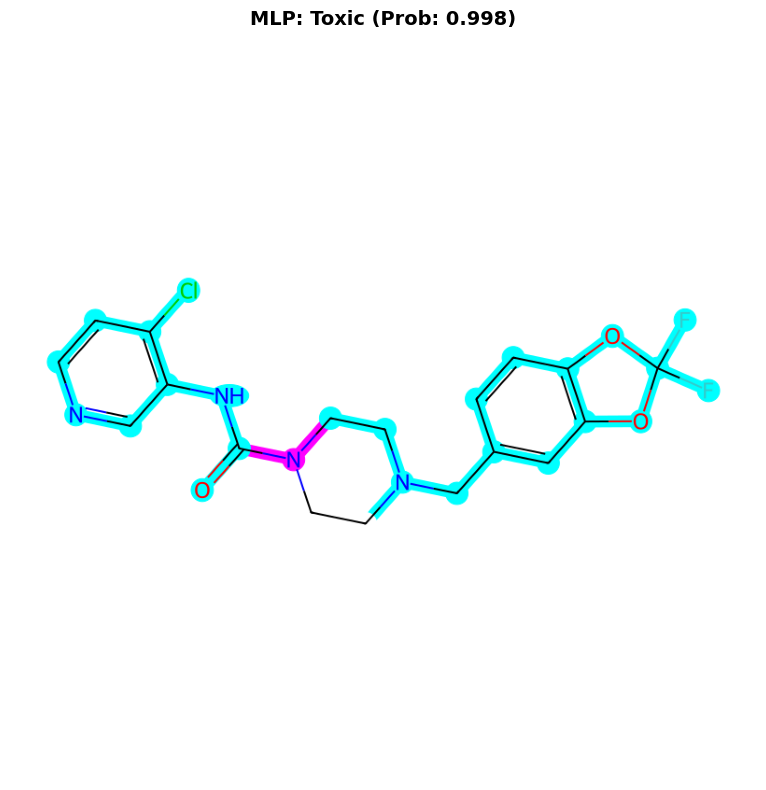

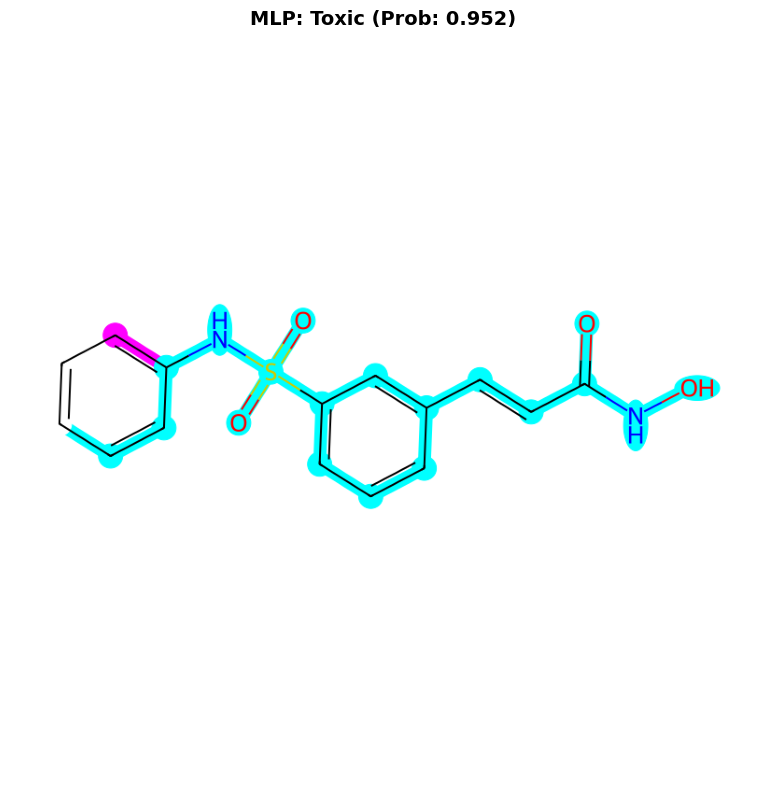

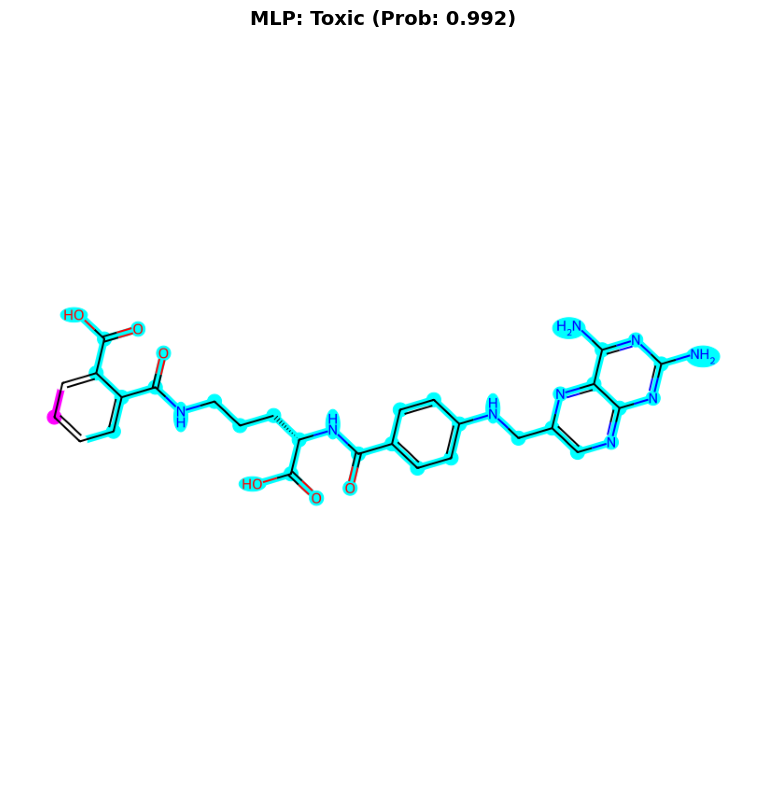

In [4]:
### MLP: Correct Toxic Predictions

if mlp_model is not None and len(correct_toxic_mlp) > 0:
    examples = correct_toxic_mlp.head(3)
    
    print("Explaining correct toxic predictions (Baseline MLP)...")
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_mlp']
        
        # Get fingerprint and explanation
        fp = featurize_batch([smiles], mode="fingerprint",
                           radius=config['featurization']['fingerprint']['radius'],
                           n_bits=config['featurization']['fingerprint']['n_bits'])[0]
        fp_tensor = torch.FloatTensor(fp).unsqueeze(0)
        
        # Get gradient attribution
        attributions, mol = explain_molecule(
            mlp_model, smiles, fp_tensor, method="gradient", device="cpu"
        )
        
        # Map fingerprint attributions to atoms
        atom_importances = map_fingerprint_to_atoms(
            smiles, attributions,
            radius=config['featurization']['fingerprint']['radius'],
            n_bits=config['featurization']['fingerprint']['n_bits']
        )
        
        # Visualize
        title = f"MLP: Toxic (Prob: {pred_prob:.3f})"
        plot_explained_molecule(smiles, atom_importances, title=title)
else:
    print("⚠ MLP model not available or no correct toxic predictions")



### MLP: Correct Non-toxic Predictions



Explaining correct non-toxic predictions (Baseline MLP)...


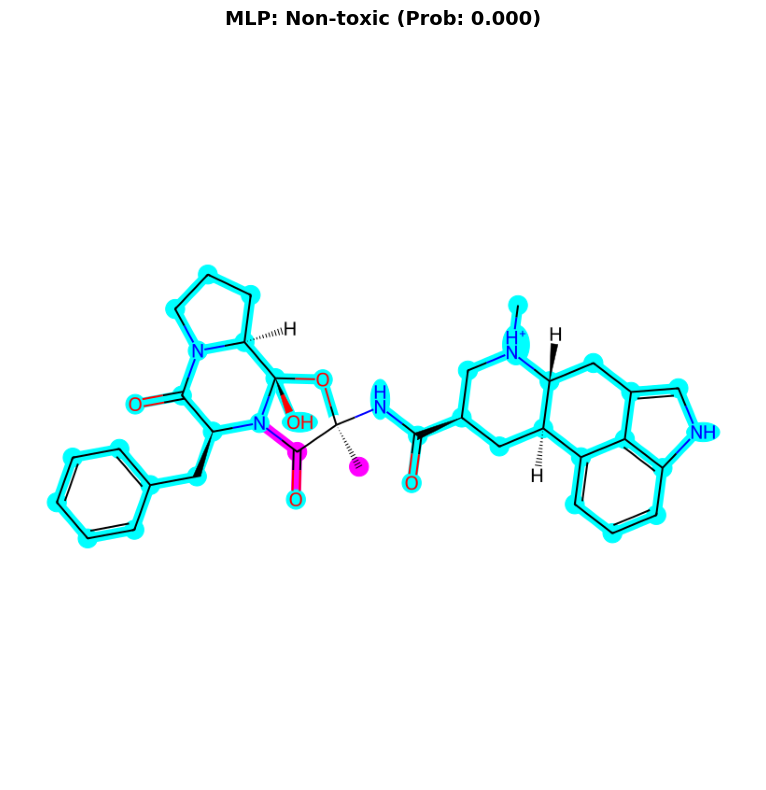

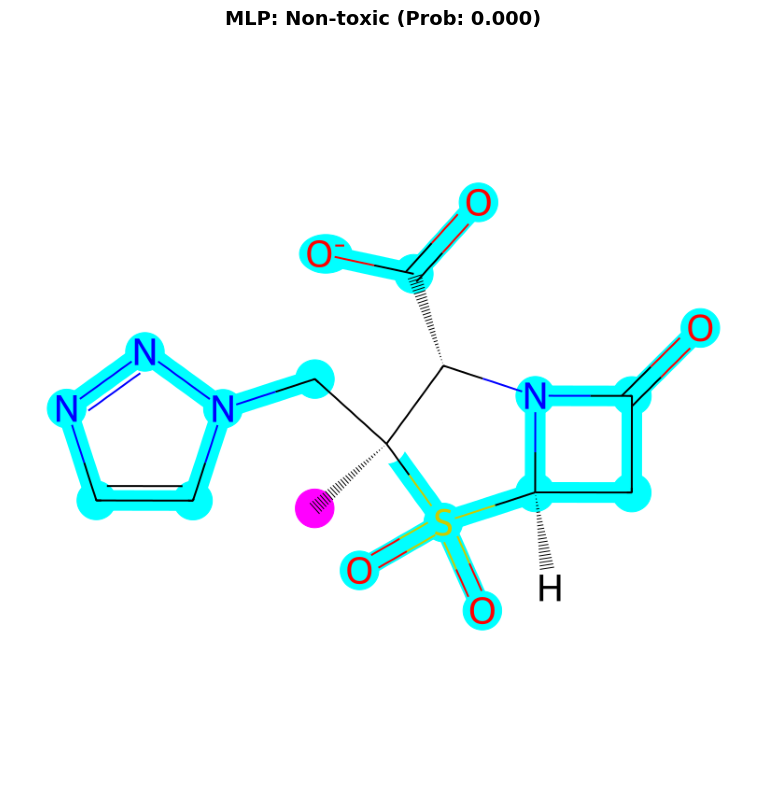

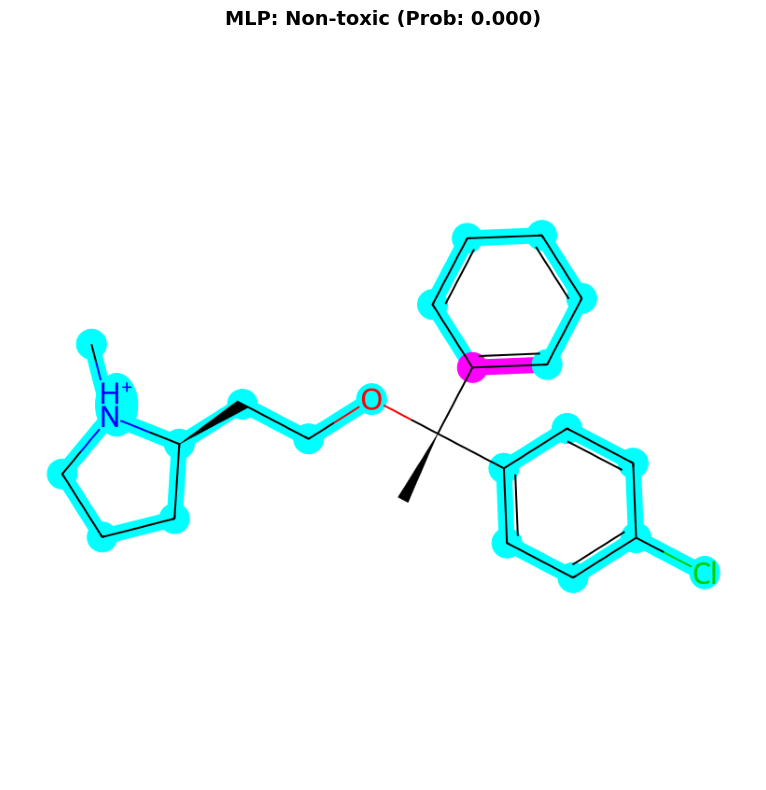

In [5]:
if mlp_model is not None and len(correct_nontoxic_mlp) > 0:
    examples = correct_nontoxic_mlp.head(3)
    
    print("Explaining correct non-toxic predictions (Baseline MLP)...")
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_mlp']
        
        # Get fingerprint and explanation
        fp = featurize_batch([smiles], mode="fingerprint",
                           radius=config['featurization']['fingerprint']['radius'],
                           n_bits=config['featurization']['fingerprint']['n_bits'])[0]
        fp_tensor = torch.FloatTensor(fp).unsqueeze(0)
        
        # Get gradient attribution
        attributions, mol = explain_molecule(
            mlp_model, smiles, fp_tensor, method="gradient", device="cpu"
        )
        
        # Map fingerprint attributions to atoms
        atom_importances = map_fingerprint_to_atoms(
            smiles, attributions,
            radius=config['featurization']['fingerprint']['radius'],
            n_bits=config['featurization']['fingerprint']['n_bits']
        )
        
        # Visualize
        title = f"MLP: Non-toxic (Prob: {pred_prob:.3f})"
        plot_explained_molecule(smiles, atom_importances, title=title)
else:
    print("⚠ MLP model not available or no correct non-toxic predictions")



### MLP: Misclassified Examples



Analyzing misclassified examples (Baseline MLP)...


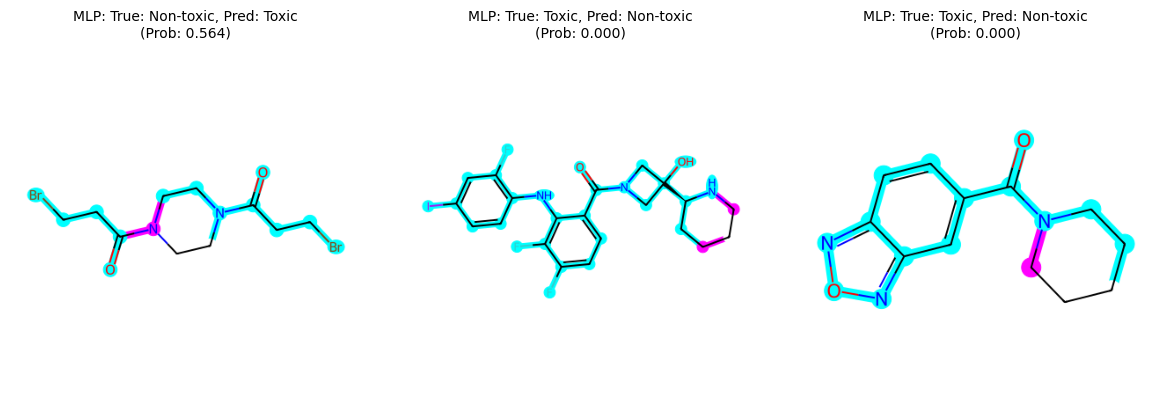

In [6]:
if mlp_model is not None and len(misclassified_mlp) > 0:
    examples = misclassified_mlp.head(3)
    
    print("Analyzing misclassified examples (Baseline MLP)...")
    smiles_list = []
    atom_importances_list = []
    titles = []
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        true_label = row['CT_TOX']
        pred_prob = row['predicted_prob_mlp']
        
        # Get fingerprint and explanation
        fp = featurize_batch([smiles], mode="fingerprint",
                           radius=config['featurization']['fingerprint']['radius'],
                           n_bits=config['featurization']['fingerprint']['n_bits'])[0]
        fp_tensor = torch.FloatTensor(fp).unsqueeze(0)
        
        # Get gradient attribution
        attributions, mol = explain_molecule(
            mlp_model, smiles, fp_tensor, method="gradient", device="cpu"
        )
        
        # Map fingerprint attributions to atoms
        atom_importances = map_fingerprint_to_atoms(
            smiles, attributions,
            radius=config['featurization']['fingerprint']['radius'],
            n_bits=config['featurization']['fingerprint']['n_bits']
        )
        
        smiles_list.append(smiles)
        atom_importances_list.append(atom_importances)
        
        true_label_str = "Toxic" if true_label == 1 else "Non-toxic"
        pred_label_str = "Toxic" if pred_prob > 0.5 else "Non-toxic"
        titles.append(f"MLP: True: {true_label_str}, Pred: {pred_label_str}\n(Prob: {pred_prob:.3f})")
    
    # Visualize grid
    plot_explained_grid(smiles_list, atom_importances_list, titles=titles, n_cols=3)
else:
    print("⚠ MLP model not available or no misclassified examples")



## BFGNN Model Explanations

Generate explanations for the BFGNN model using graph-based attribution methods.

**Method:** Perturbation-based attribution (systematically removing atoms and measuring prediction changes).




In [7]:
# Identify examples for BFGNN visualization
if bfgnn_model is not None:
    correct_toxic_bfgnn = test_df[(test_df['CT_TOX'] == 1) & (test_df['correct_bfgnn'] == True)]
    correct_nontoxic_bfgnn = test_df[(test_df['CT_TOX'] == 0) & (test_df['correct_bfgnn'] == True)]
    misclassified_bfgnn = test_df[test_df['correct_bfgnn'] == False]
    
    print(f"\nBFGNN Statistics:")
    print(f"  Correct toxic: {len(correct_toxic_bfgnn)}")
    print(f"  Correct non-toxic: {len(correct_nontoxic_bfgnn)}")
    print(f"  Misclassified: {len(misclassified_bfgnn)}")
else:
    correct_toxic_bfgnn = None
    correct_nontoxic_bfgnn = None
    misclassified_bfgnn = None



BFGNN Statistics:
  Correct toxic: 1
  Correct non-toxic: 138
  Misclassified: 9


### BFGNN: Correct Toxic Predictions


Explaining correct toxic predictions (BFGNN)...
Using perturbation-based attribution (removing atoms and measuring prediction changes)...



Predicting: 100%|██████████| 1/1 [00:00<00:00, 371.08it/s]


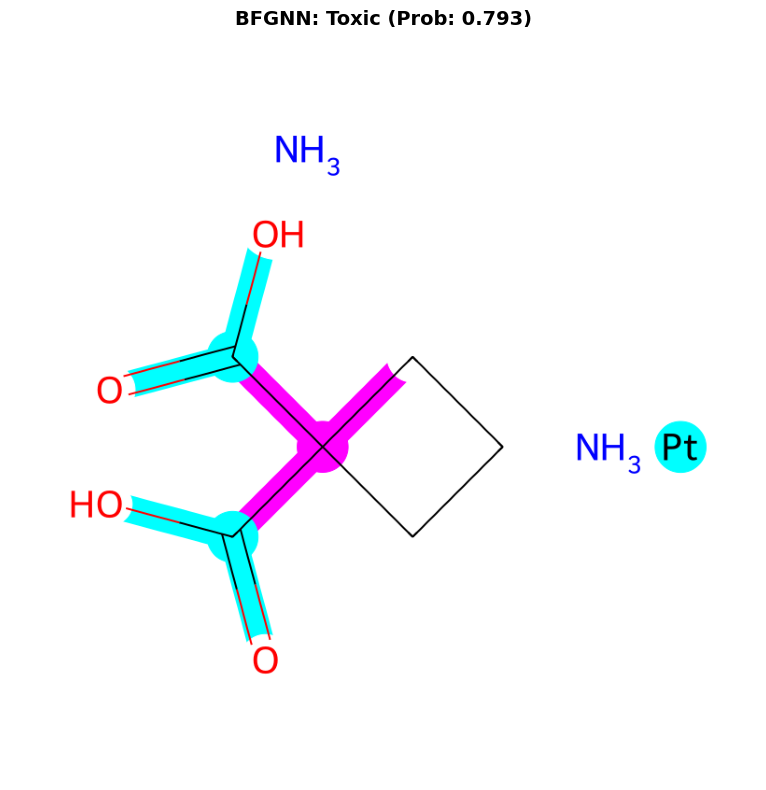

In [8]:
if bfgnn_model is not None and correct_toxic_bfgnn is not None and len(correct_toxic_bfgnn) > 0:
    examples = correct_toxic_bfgnn.head(3)
    
    print("Explaining correct toxic predictions (BFGNN)...")
    print("Using perturbation-based attribution (removing atoms and measuring prediction changes)...")
    print()
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_bfgnn']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                bfgnn_model, smiles, method="perturbation"
            )
            title = f"BFGNN: Toxic (Prob: {pred_prob:.3f})"
            plot_explained_molecule(smiles, np.array(atom_importances), title=title)
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
else:
    if bfgnn_model is None:
        print("⚠ BFGNN model not available")
    elif correct_toxic_bfgnn is None or len(correct_toxic_bfgnn) == 0:
        print("⚠ No correct toxic predictions available for BFGNN")


### BFGNN: Correct Non-toxic Predictions


Explaining correct non-toxic predictions (BFGNN)...


Predicting: 100%|██████████| 1/1 [00:00<00:00, 336.81it/s]


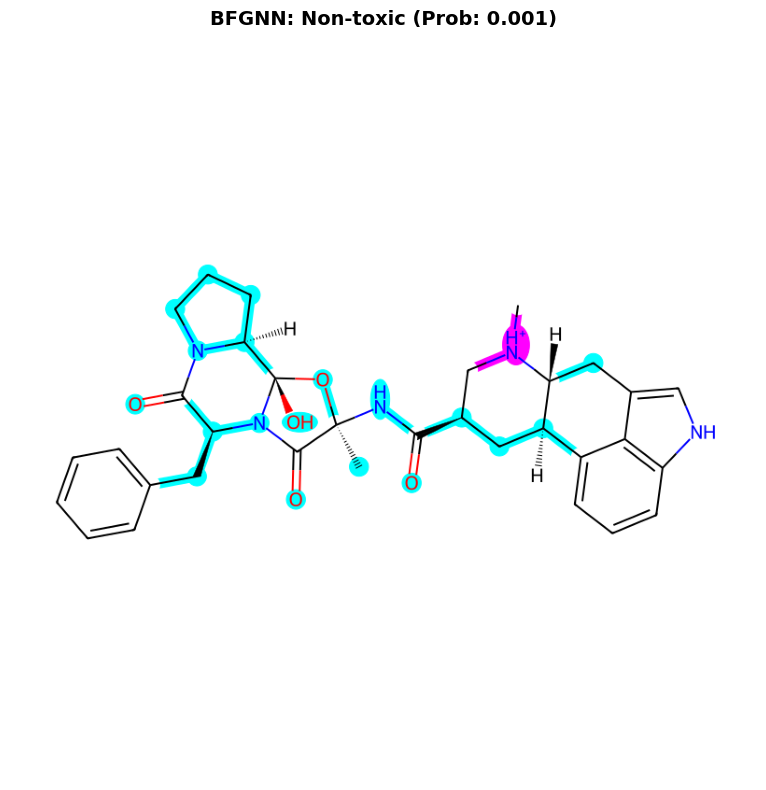

Predicting: 100%|██████████| 1/1 [00:00<00:00, 324.49it/s]


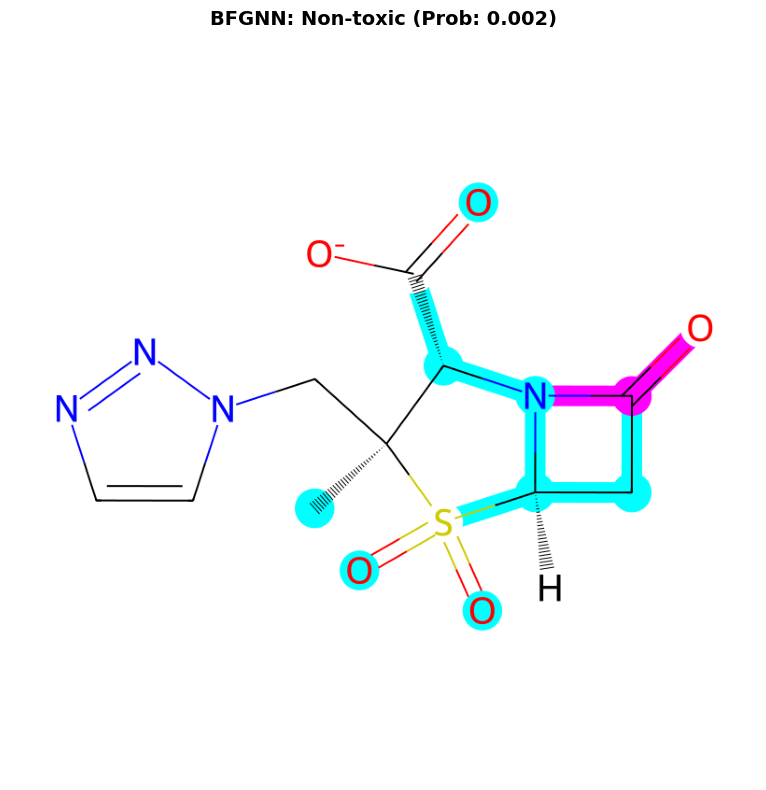

Predicting: 100%|██████████| 1/1 [00:00<00:00, 288.92it/s]


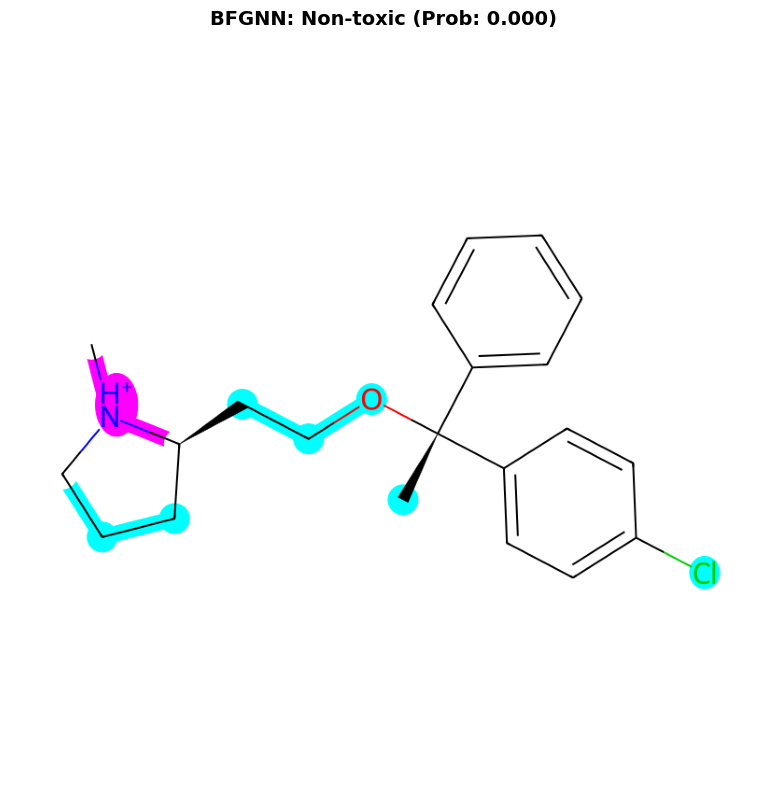

In [9]:
if bfgnn_model is not None and correct_nontoxic_bfgnn is not None and len(correct_nontoxic_bfgnn) > 0:
    examples = correct_nontoxic_bfgnn.head(3)
    
    print("Explaining correct non-toxic predictions (BFGNN)...")
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_bfgnn']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                bfgnn_model, smiles, method="perturbation"
            )
            title = f"BFGNN: Non-toxic (Prob: {pred_prob:.3f})"
            plot_explained_molecule(smiles, np.array(atom_importances), title=title)
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
else:
    if bfgnn_model is None:
        print("⚠ BFGNN model not available")
    elif correct_nontoxic_bfgnn is None or len(correct_nontoxic_bfgnn) == 0:
        print("⚠ No correct non-toxic predictions available for BFGNN")


### BFGNN: Misclassified Examples


Analyzing misclassified examples (BFGNN)...


Predicting: 100%|██████████| 1/1 [00:00<00:00, 378.68it/s]


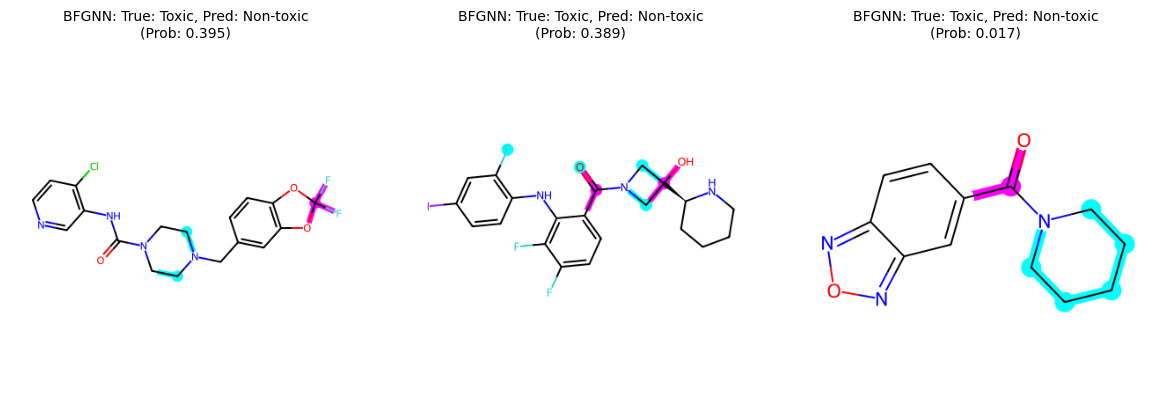

In [10]:
if bfgnn_model is not None and misclassified_bfgnn is not None and len(misclassified_bfgnn) > 0:
    examples = misclassified_bfgnn.head(3)
    
    print("Analyzing misclassified examples (BFGNN)...")
    smiles_list = []
    atom_importances_list = []
    titles = []
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        true_label = row['CT_TOX']
        pred_prob = row['predicted_prob_bfgnn']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                bfgnn_model, smiles, method="perturbation"
            )
            smiles_list.append(smiles)
            atom_importances_list.append(np.array(atom_importances))
            
            true_label_str = "Toxic" if true_label == 1 else "Non-toxic"
            pred_label_str = "Toxic" if pred_prob > 0.5 else "Non-toxic"
            titles.append(f"BFGNN: True: {true_label_str}, Pred: {pred_label_str}\n(Prob: {pred_prob:.3f})")
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
    
    if len(smiles_list) > 0:
        plot_explained_grid(smiles_list, atom_importances_list, titles=titles, n_cols=3)
else:
    if bfgnn_model is None:
        print("⚠ BFGNN model not available")
    elif misclassified_bfgnn is None or len(misclassified_bfgnn) == 0:
        print("⚠ No misclassified examples available for BFGNN")


## GRIN Model Explanations

Generate explanations for the GRIN model using graph-based attribution methods.

**Method:** Perturbation-based attribution (systematically removing atoms and measuring prediction changes).


In [11]:
# Identify examples for GRIN visualization
if grin_model is not None:
    correct_toxic_grin = test_df[(test_df['CT_TOX'] == 1) & (test_df['correct_grin'] == True)]
    correct_nontoxic_grin = test_df[(test_df['CT_TOX'] == 0) & (test_df['correct_grin'] == True)]
    misclassified_grin = test_df[test_df['correct_grin'] == False]
    
    print(f"\nGRIN Statistics:")
    print(f"  Correct toxic: {len(correct_toxic_grin)}")
    print(f"  Correct non-toxic: {len(correct_nontoxic_grin)}")
    print(f"  Misclassified: {len(misclassified_grin)}")
else:
    correct_toxic_grin = None
    correct_nontoxic_grin = None
    misclassified_grin = None



GRIN Statistics:
  Correct toxic: 3
  Correct non-toxic: 137
  Misclassified: 8


### GRIN: Correct Toxic Predictions


Explaining correct toxic predictions (GRIN)...
Using perturbation-based attribution (removing atoms and measuring prediction changes)...



Predicting: 100%|██████████| 1/1 [00:00<00:00, 281.06it/s]


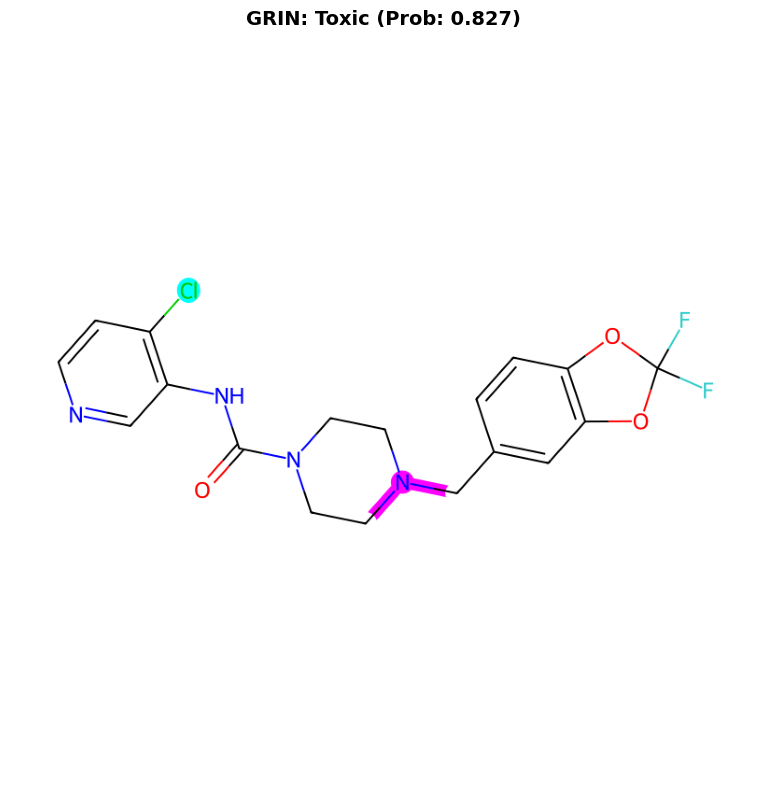

Predicting: 100%|██████████| 1/1 [00:00<00:00, 252.33it/s]


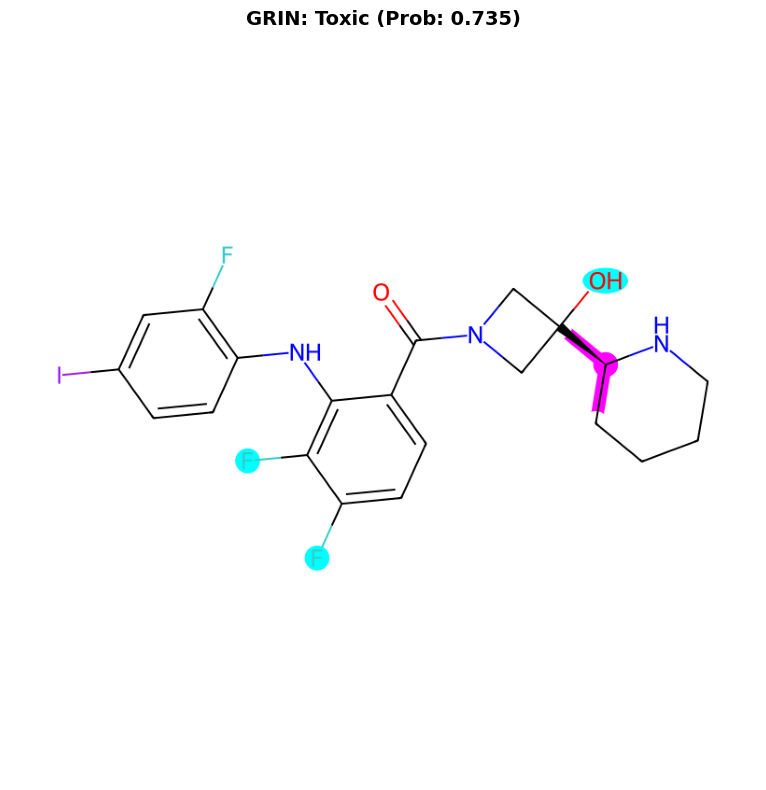

Predicting: 100%|██████████| 1/1 [00:00<00:00, 307.32it/s]


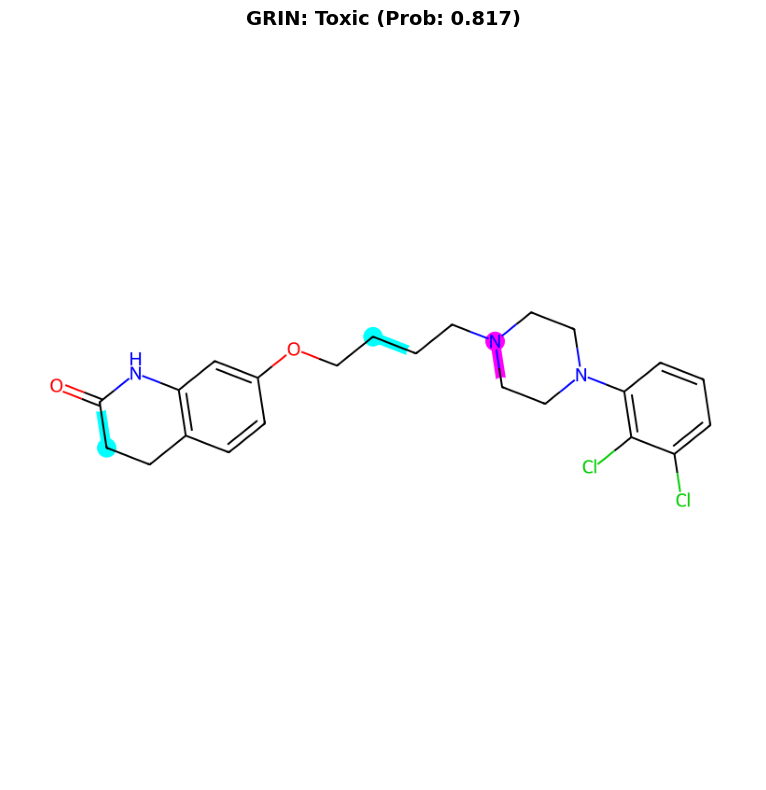

In [12]:
if grin_model is not None and correct_toxic_grin is not None and len(correct_toxic_grin) > 0:
    examples = correct_toxic_grin.head(3)
    
    print("Explaining correct toxic predictions (GRIN)...")
    print("Using perturbation-based attribution (removing atoms and measuring prediction changes)...")
    print()
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_grin']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                grin_model, smiles, method="perturbation"
            )
            title = f"GRIN: Toxic (Prob: {pred_prob:.3f})"
            plot_explained_molecule(smiles, np.array(atom_importances), title=title)
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
else:
    if grin_model is None:
        print("⚠ GRIN model not available")
    elif correct_toxic_grin is None or len(correct_toxic_grin) == 0:
        print("⚠ No correct toxic predictions available for GRIN")


### GRIN: Correct Non-toxic Predictions


Explaining correct non-toxic predictions (GRIN)...


Predicting: 100%|██████████| 1/1 [00:00<00:00, 260.14it/s]


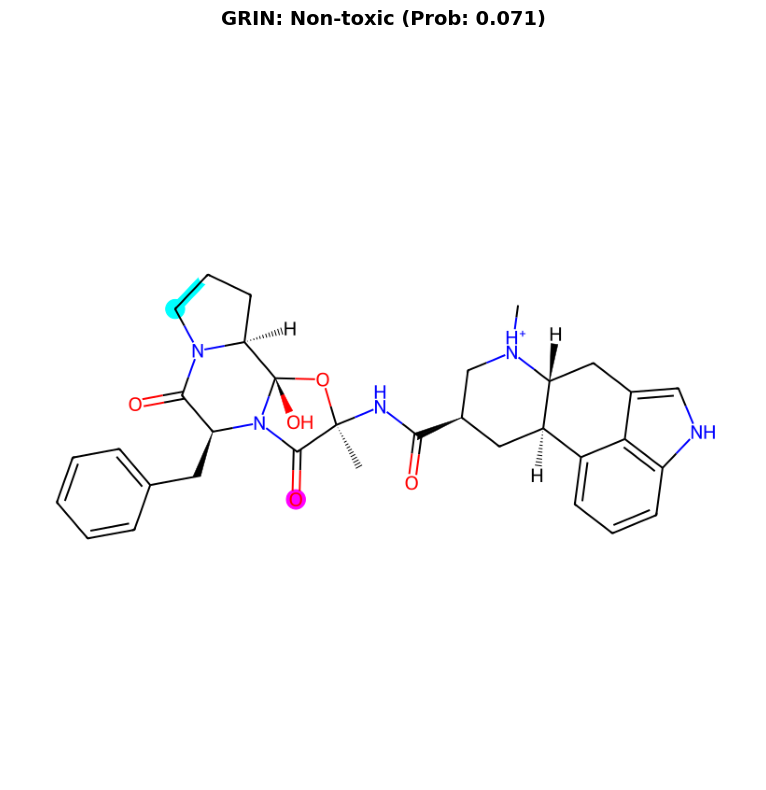

Predicting: 100%|██████████| 1/1 [00:00<00:00, 265.33it/s]


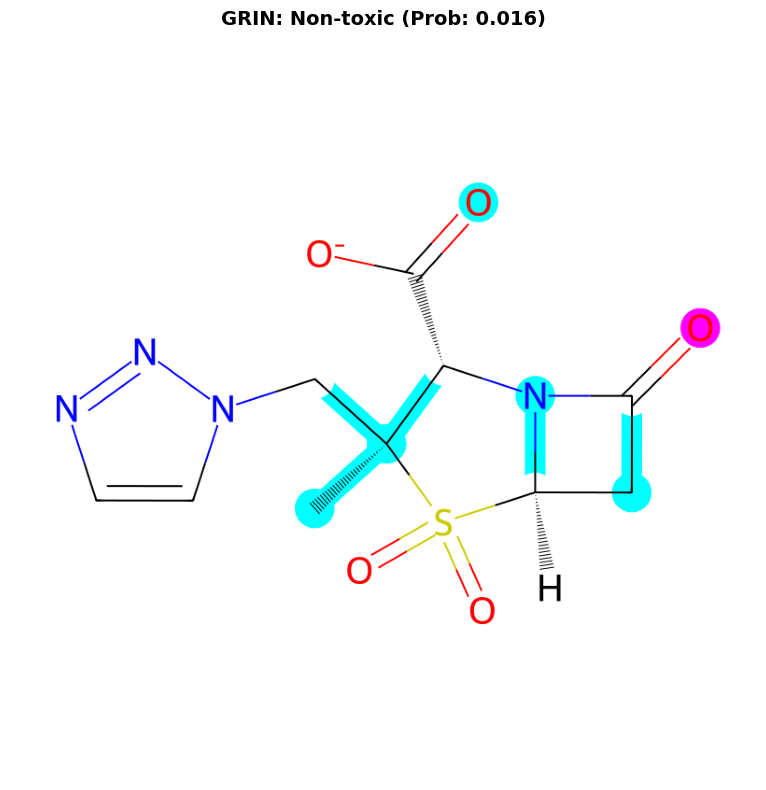

Predicting: 100%|██████████| 1/1 [00:00<00:00, 251.62it/s]


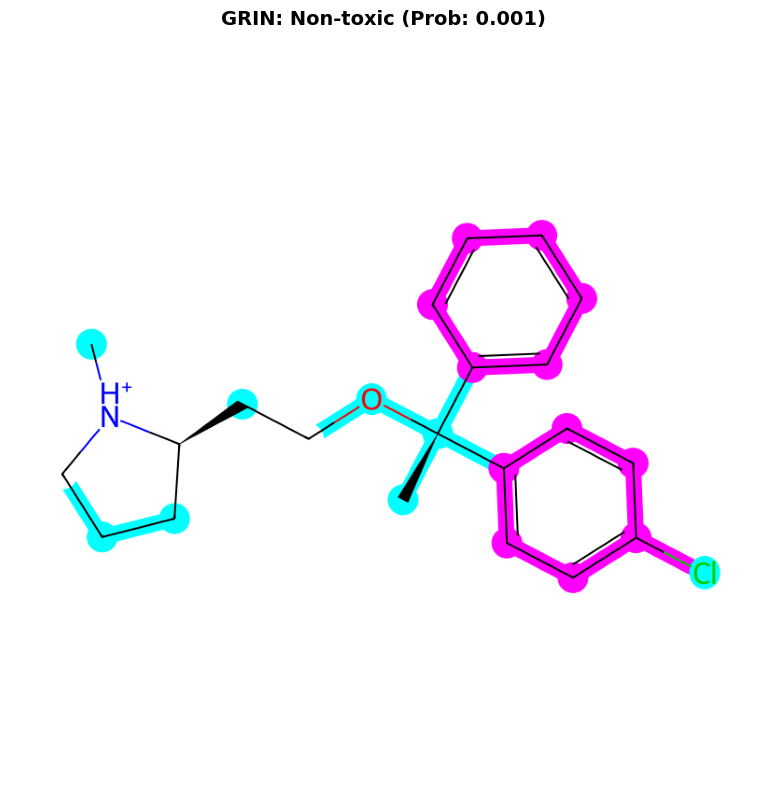

In [13]:
if grin_model is not None and correct_nontoxic_grin is not None and len(correct_nontoxic_grin) > 0:
    examples = correct_nontoxic_grin.head(3)
    
    print("Explaining correct non-toxic predictions (GRIN)...")
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_grin']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                grin_model, smiles, method="perturbation"
            )
            title = f"GRIN: Non-toxic (Prob: {pred_prob:.3f})"
            plot_explained_molecule(smiles, np.array(atom_importances), title=title)
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
else:
    if grin_model is None:
        print("⚠ GRIN model not available")
    elif correct_nontoxic_grin is None or len(correct_nontoxic_grin) == 0:
        print("⚠ No correct non-toxic predictions available for GRIN")


### GRIN: Misclassified Examples


Analyzing misclassified examples (GRIN)...


Predicting: 100%|██████████| 1/1 [00:00<00:00, 302.21it/s]


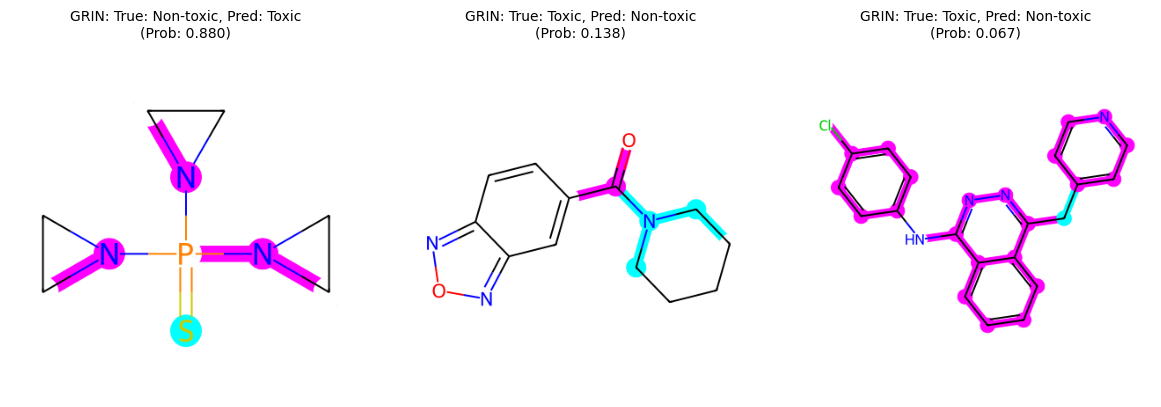

In [14]:
if grin_model is not None and misclassified_grin is not None and len(misclassified_grin) > 0:
    examples = misclassified_grin.head(3)
    
    print("Analyzing misclassified examples (GRIN)...")
    smiles_list = []
    atom_importances_list = []
    titles = []
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        true_label = row['CT_TOX']
        pred_prob = row['predicted_prob_grin']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                grin_model, smiles, method="perturbation"
            )
            smiles_list.append(smiles)
            atom_importances_list.append(np.array(atom_importances))
            
            true_label_str = "Toxic" if true_label == 1 else "Non-toxic"
            pred_label_str = "Toxic" if pred_prob > 0.5 else "Non-toxic"
            titles.append(f"GRIN: True: {true_label_str}, Pred: {pred_label_str}\n(Prob: {pred_prob:.3f})")
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
    
    if len(smiles_list) > 0:
        plot_explained_grid(smiles_list, atom_importances_list, titles=titles, n_cols=3)
else:
    if grin_model is None:
        print("⚠ GRIN model not available")
    elif misclassified_grin is None or len(misclassified_grin) == 0:
        print("⚠ No misclassified examples available for GRIN")


## SMILESTransformer Model Explanations

Generate explanations for the SMILESTransformer model using graph-based attribution methods.

**Method:** Perturbation-based attribution (systematically removing atoms and measuring prediction changes).

**Note:** SMILESTransformer uses Transformer architecture on SMILES strings, treating molecules as sequences rather than graph structures. However, for explainability, we can still use perturbation-based attribution by removing atoms from the molecular graph representation.


In [15]:
# Identify examples for SMILESTransformer visualization
if smilestransformer_model is not None:
    correct_toxic_smilestransformer = test_df[(test_df['CT_TOX'] == 1) & (test_df['correct_smilestransformer'] == True)]
    correct_nontoxic_smilestransformer = test_df[(test_df['CT_TOX'] == 0) & (test_df['correct_smilestransformer'] == True)]
    misclassified_smilestransformer = test_df[test_df['correct_smilestransformer'] == False]
    
    print(f"\nSMILESTransformer Statistics:")
    print(f"  Correct toxic: {len(correct_toxic_smilestransformer)}")
    print(f"  Correct non-toxic: {len(correct_nontoxic_smilestransformer)}")
    print(f"  Misclassified: {len(misclassified_smilestransformer)}")
else:
    correct_toxic_smilestransformer = None
    correct_nontoxic_smilestransformer = None
    misclassified_smilestransformer = None



SMILESTransformer Statistics:
  Correct toxic: 9
  Correct non-toxic: 134
  Misclassified: 5


### SMILESTransformer: Correct Toxic Predictions


Explaining correct toxic predictions (SMILESTransformer)...
Using perturbation-based attribution (removing atoms and measuring prediction changes)...



100%|██████████| 1/1 [00:00<00:00, 231.65it/s]


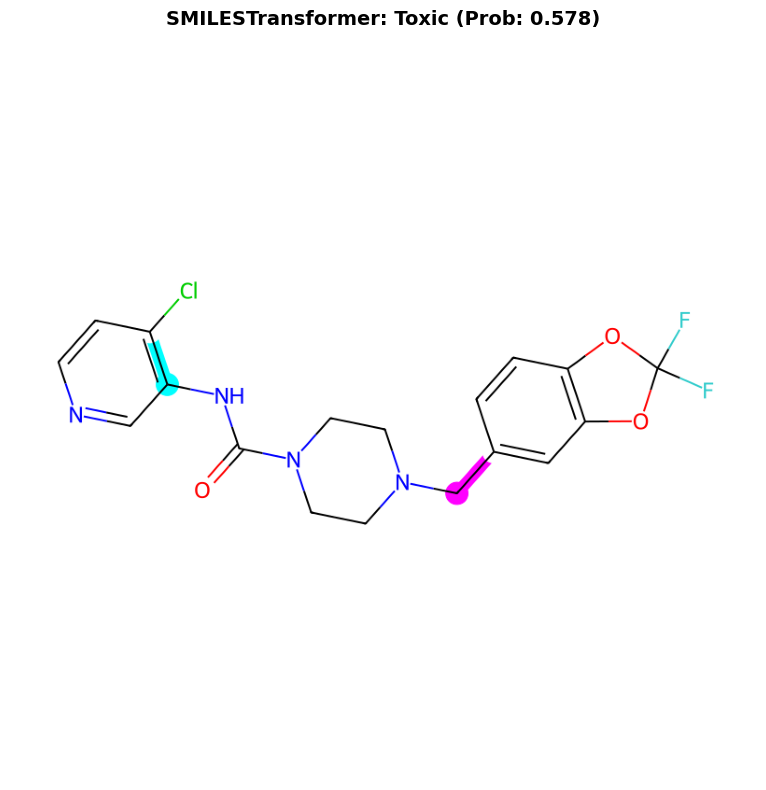

100%|██████████| 1/1 [00:00<00:00, 34.42it/s]


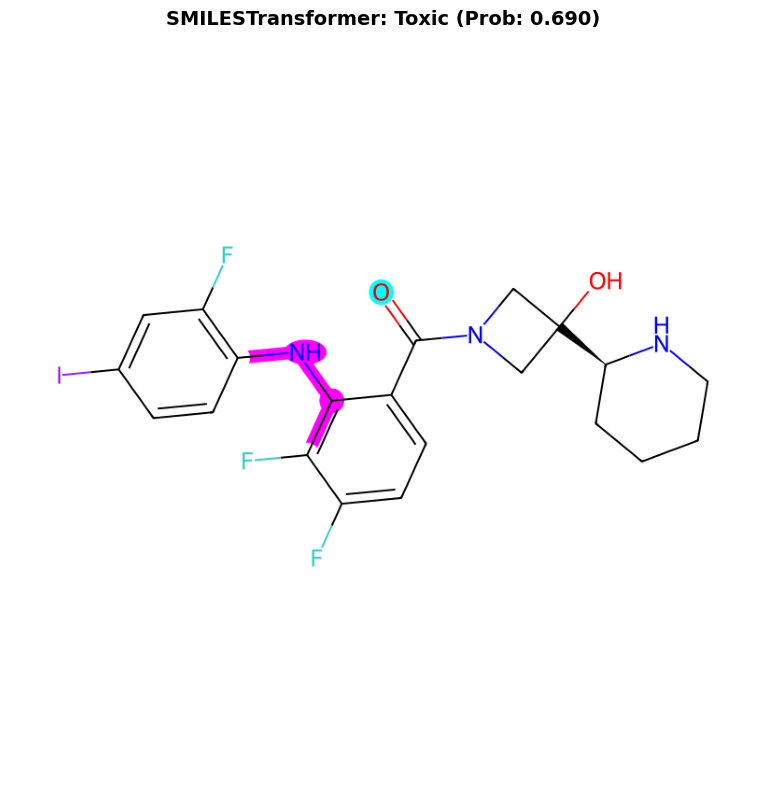

100%|██████████| 1/1 [00:00<00:00, 166.41it/s]


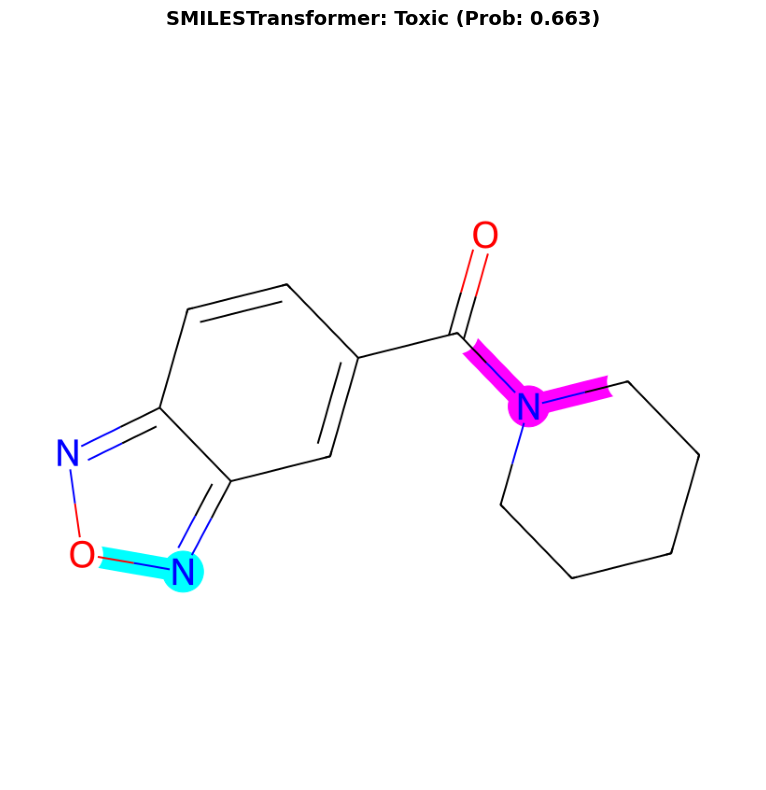

In [16]:
if smilestransformer_model is not None and correct_toxic_smilestransformer is not None and len(correct_toxic_smilestransformer) > 0:
    examples = correct_toxic_smilestransformer.head(3)
    
    print("Explaining correct toxic predictions (SMILESTransformer)...")
    print("Using perturbation-based attribution (removing atoms and measuring prediction changes)...")
    print()
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_smilestransformer']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                smilestransformer_model, smiles, method="perturbation"
            )
            title = f"SMILESTransformer: Toxic (Prob: {pred_prob:.3f})"
            plot_explained_molecule(smiles, np.array(atom_importances), title=title)
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
else:
    if smilestransformer_model is None:
        print("⚠ SMILESTransformer model not available")
    elif correct_toxic_smilestransformer is None or len(correct_toxic_smilestransformer) == 0:
        print("⚠ No correct toxic predictions available for SMILESTransformer")


### SMILESTransformer: Correct Non-toxic Predictions


Explaining correct non-toxic predictions (SMILESTransformer)...


100%|██████████| 1/1 [00:00<00:00, 283.36it/s]


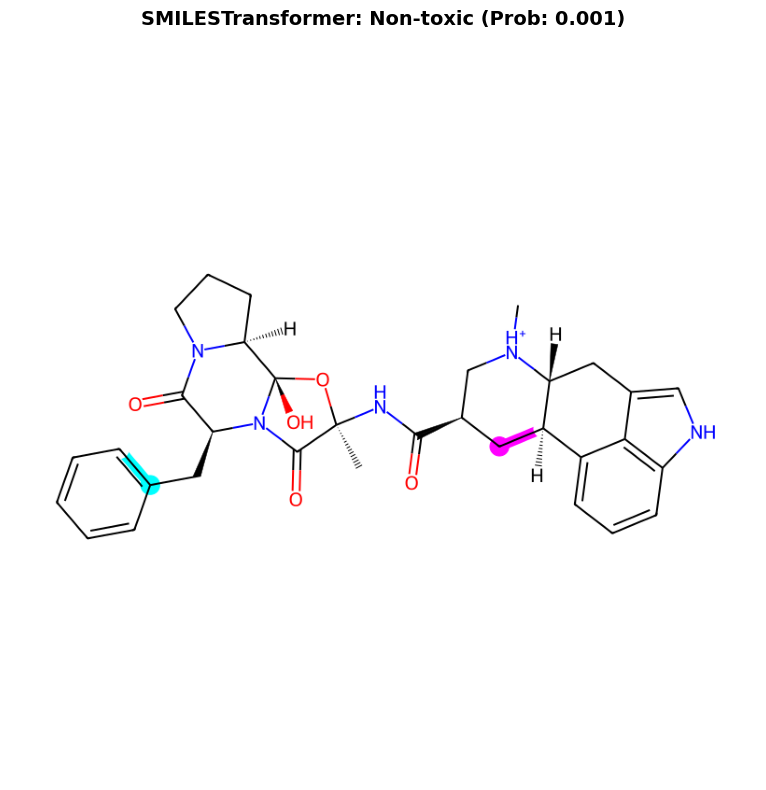

100%|██████████| 1/1 [00:00<00:00, 202.52it/s]


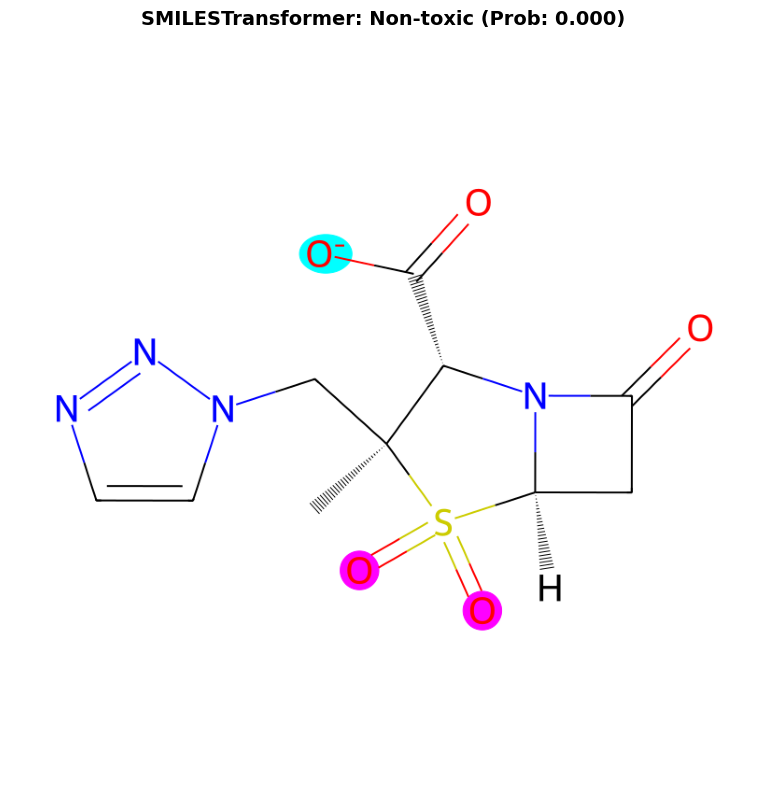

100%|██████████| 1/1 [00:00<00:00, 245.04it/s]


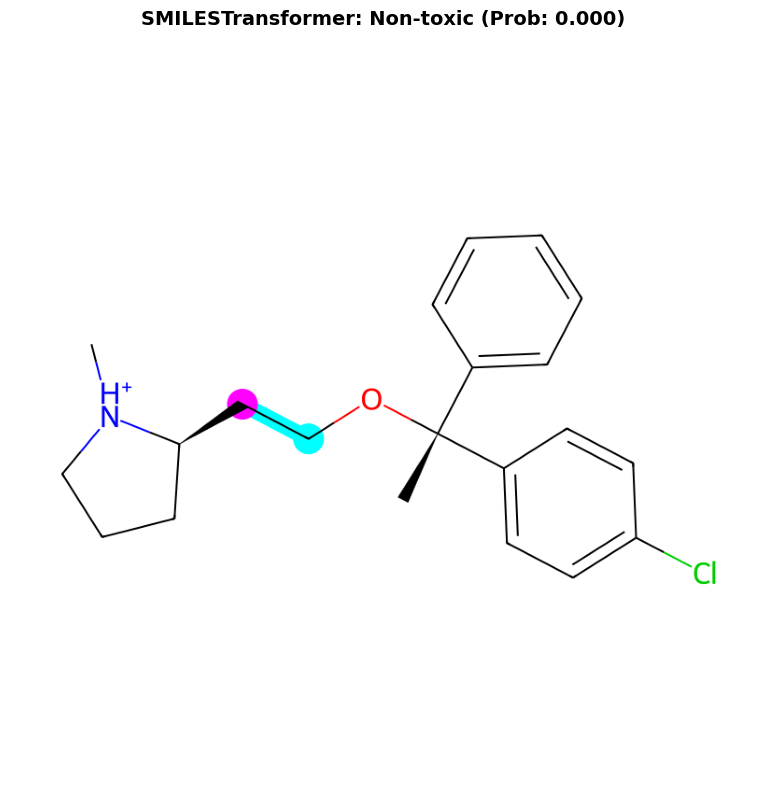

In [17]:
if smilestransformer_model is not None and correct_nontoxic_smilestransformer is not None and len(correct_nontoxic_smilestransformer) > 0:
    examples = correct_nontoxic_smilestransformer.head(3)
    
    print("Explaining correct non-toxic predictions (SMILESTransformer)...")
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        pred_prob = row['predicted_prob_smilestransformer']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                smilestransformer_model, smiles, method="perturbation"
            )
            title = f"SMILESTransformer: Non-toxic (Prob: {pred_prob:.3f})"
            plot_explained_molecule(smiles, np.array(atom_importances), title=title)
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
else:
    if smilestransformer_model is None:
        print("⚠ SMILESTransformer model not available")
    elif correct_nontoxic_smilestransformer is None or len(correct_nontoxic_smilestransformer) == 0:
        print("⚠ No correct non-toxic predictions available for SMILESTransformer")


### SMILESTransformer: Misclassified Examples


Analyzing misclassified examples (SMILESTransformer)...


100%|██████████| 1/1 [00:00<00:00, 343.51it/s]


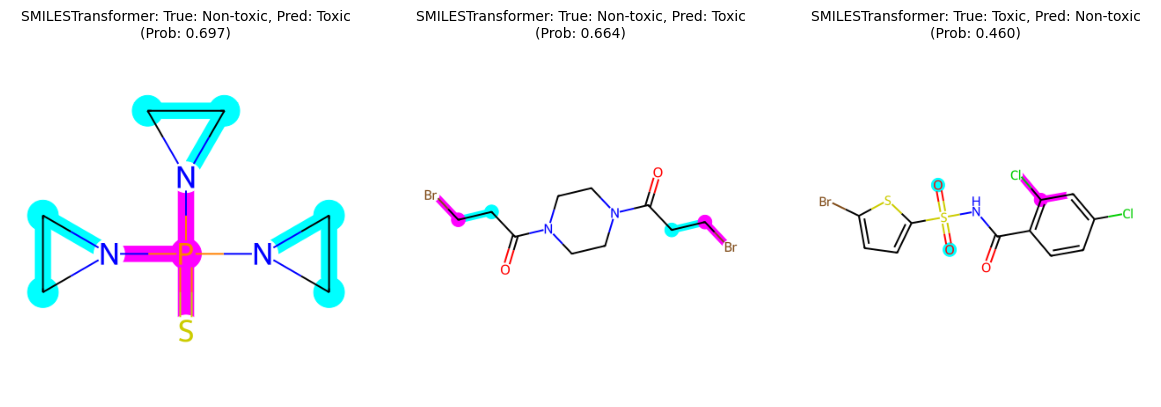

In [18]:
if smilestransformer_model is not None and misclassified_smilestransformer is not None and len(misclassified_smilestransformer) > 0:
    examples = misclassified_smilestransformer.head(3)
    
    print("Analyzing misclassified examples (SMILESTransformer)...")
    smiles_list = []
    atom_importances_list = []
    titles = []
    
    for idx, row in examples.iterrows():
        smiles = row['smiles']
        true_label = row['CT_TOX']
        pred_prob = row['predicted_prob_smilestransformer']
        
        try:
            atom_importances, mol = explain_torch_molecule_model(
                smilestransformer_model, smiles, method="perturbation"
            )
            smiles_list.append(smiles)
            atom_importances_list.append(np.array(atom_importances))
            
            true_label_str = "Toxic" if true_label == 1 else "Non-toxic"
            pred_label_str = "Toxic" if pred_prob > 0.5 else "Non-toxic"
            titles.append(f"SMILESTransformer: True: {true_label_str}, Pred: {pred_label_str}\n(Prob: {pred_prob:.3f})")
        except Exception as e:
            print(f"⚠ Error explaining molecule {smiles}: {e}")
    
    if len(smiles_list) > 0:
        plot_explained_grid(smiles_list, atom_importances_list, titles=titles, n_cols=3)
else:
    if smilestransformer_model is None:
        print("⚠ SMILESTransformer model not available")
    elif misclassified_smilestransformer is None or len(misclassified_smilestransformer) == 0:
        print("⚠ No misclassified examples available for SMILESTransformer")


## SMILESTransformer Representation Visualization

Visualize how SMILESTransformer processes molecules as sequences, showing tokenization and sequence-based representation.

Unlike graph-based models (BFGNN, GRIN) that process molecules as graphs with atoms and bonds, SMILESTransformer treats molecules as sequences of tokens in SMILES notation. This section demonstrates:

1. **SMILES Tokenization**: How molecules are broken down into tokens
2. **Sequence Representation**: Visualizing molecules as sequences vs graphs
3. **Token-level Analysis**: Understanding the sequence structure



SMILESTransformer Sequence Representation

SMILESTransformer processes molecules as sequences of tokens,
unlike graph-based models that process them as graphs.


Visualizing 2 example(s)...
✓ Tokenization visualization saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/04_smilestransformer_tokenization.png


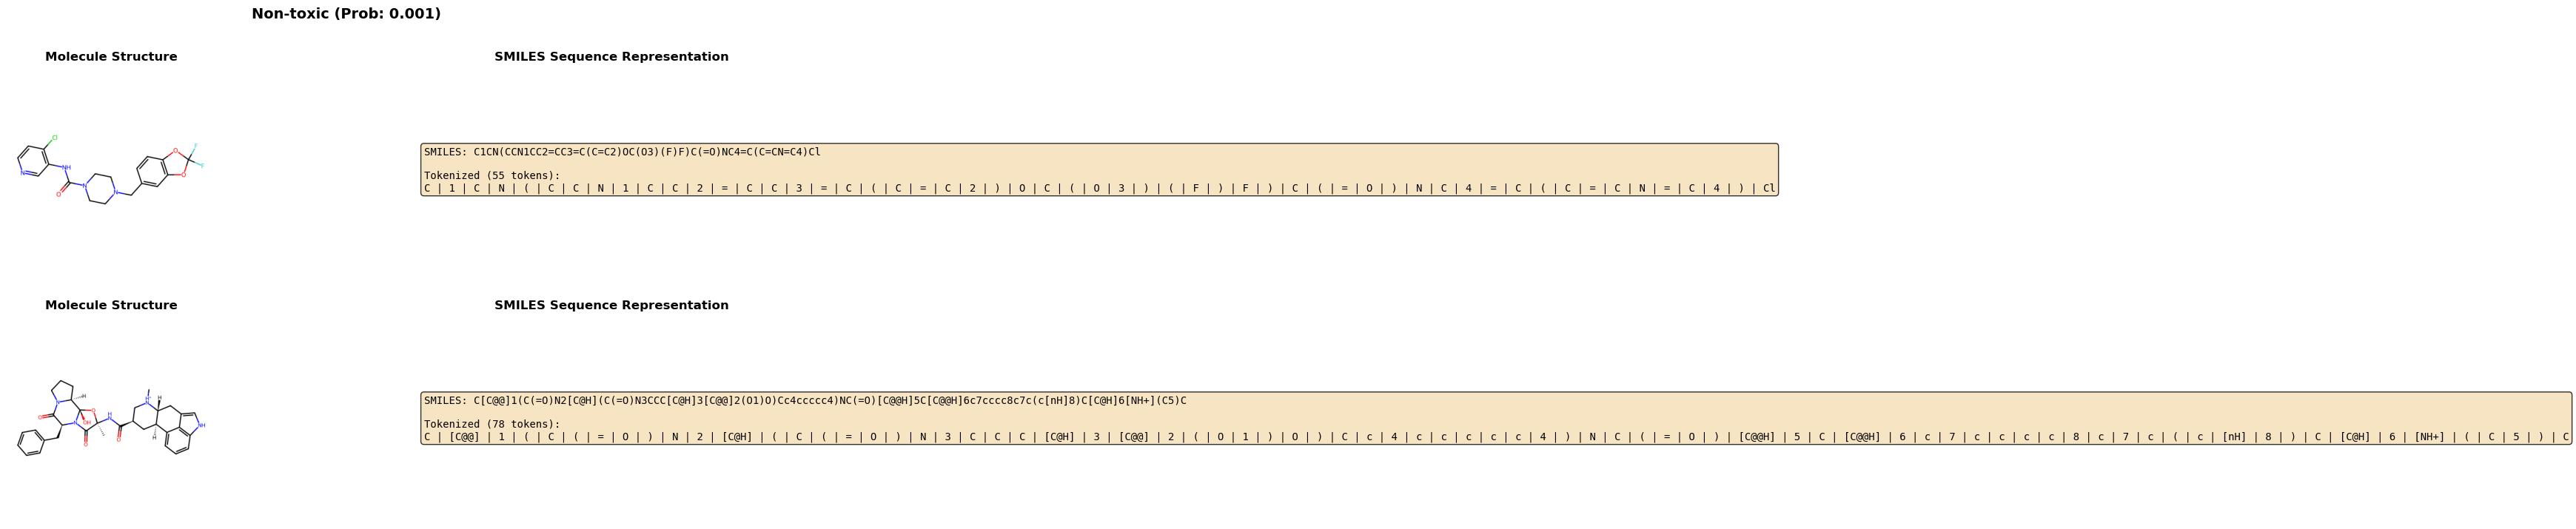


Tokenization Statistics

Toxic (Prob: 0.578):
  SMILES: C1CN(CCN1CC2=CC3=C(C=C2)OC(O3)(F)F)C(=O)NC4=C(C=CN=C4)Cl
  Number of tokens: 55
  Number of atoms: 28
  Tokens: C 1 C N ( C C N 1 C C 2 = C C 3 = C ( C...
  Token/Atom ratio: 1.96

Non-toxic (Prob: 0.001):
  SMILES: C[C@@]1(C(=O)N2[C@H](C(=O)N3CCC[C@H]3[C@@]2(O1)O)Cc4ccccc4)NC(=O)[C@@H]5C[C@@H]6c7cccc8c7c(c[nH]8)C[C@H]6[NH+](C5)C
  Number of tokens: 78
  Number of atoms: 43
  Tokens: C [C@@] 1 ( C ( = O ) N 2 [C@H] ( C ( = O ) N 3...
  Token/Atom ratio: 1.81


In [19]:
# Visualize SMILESTransformer sequence representation
from rdkit import Chem
from rdkit.Chem import Draw
from src.featurization import smiles_to_mol
import re

def tokenize_smiles(smiles):
    """
    Tokenize a SMILES string into tokens.
    This is a simple tokenizer - torch-molecule may use a more sophisticated one.
    """
    # Pattern to match SMILES tokens: atoms, bonds, rings, branches, etc.
    pattern = r"(\[[^\]]+\]|Br|Cl|[BCNOPSFIHbcnospfi]|\d+|\(|\)|\.|=|#|@|/|\\|-)"
    tokens = re.findall(pattern, smiles)
    return tokens

def visualize_smiles_tokenization(smiles_list, labels_list=None):
    """Visualize SMILES strings with tokenization"""
    n_mols = len(smiles_list)
    fig, axes = plt.subplots(n_mols, 2, figsize=(16, 4*n_mols))
    if n_mols == 1:
        axes = axes.reshape(1, -1)
    
    for idx, smiles in enumerate(smiles_list):
        # Left: Molecular structure
        mol = smiles_to_mol(smiles)
        if mol is not None:
            img = Draw.MolToImage(mol, size=(400, 400))
            axes[idx, 0].imshow(img)
            axes[idx, 0].axis('off')
            axes[idx, 0].set_title(f'Molecule Structure', fontsize=12, fontweight='bold')
        
        # Right: SMILES string with tokenization
        tokens = tokenize_smiles(smiles)
        axes[idx, 1].axis('off')
        
        # Create a text visualization showing tokens
        token_str = ' | '.join(tokens)
        axes[idx, 1].text(0.05, 0.5, f'SMILES: {smiles}\n\nTokenized ({len(tokens)} tokens):\n{token_str}', 
                         fontsize=10, family='monospace', 
                         verticalalignment='center', 
                         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        axes[idx, 1].set_title(f'SMILES Sequence Representation', fontsize=12, fontweight='bold')
        
        if labels_list and idx < len(labels_list):
            fig.suptitle(labels_list[idx], fontsize=14, fontweight='bold', y=0.98 if idx == 0 else None)
    
    plt.tight_layout()
    return fig

if smilestransformer_model is not None:
    print("=" * 80)
    print("SMILESTransformer Sequence Representation")
    print("=" * 80)
    print("\nSMILESTransformer processes molecules as sequences of tokens,")
    print("unlike graph-based models that process them as graphs.\n")
    
    # Select examples: one toxic, one non-toxic
    example_smiles = []
    example_labels = []
    
    if correct_toxic_smilestransformer is not None and len(correct_toxic_smilestransformer) > 0:
        toxic_example = correct_toxic_smilestransformer.iloc[0]
        example_smiles.append(toxic_example['smiles'])
        example_labels.append(f"Toxic (Prob: {toxic_example['predicted_prob_smilestransformer']:.3f})")
    
    if correct_nontoxic_smilestransformer is not None and len(correct_nontoxic_smilestransformer) > 0:
        nontoxic_example = correct_nontoxic_smilestransformer.iloc[0]
        example_smiles.append(nontoxic_example['smiles'])
        example_labels.append(f"Non-toxic (Prob: {nontoxic_example['predicted_prob_smilestransformer']:.3f})")
    
    if len(example_smiles) > 0:
        print(f"\nVisualizing {len(example_smiles)} example(s)...")
        fig = visualize_smiles_tokenization(example_smiles, example_labels)
        
        # Save figure
        figures_dir = project_root / "output" / "figures"
        figures_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(figures_dir / "04_smilestransformer_tokenization.png", dpi=300, bbox_inches='tight')
        print(f"✓ Tokenization visualization saved to: {figures_dir / '04_smilestransformer_tokenization.png'}")
        plt.show()
        
        # Print tokenization statistics
        print("\n" + "=" * 80)
        print("Tokenization Statistics")
        print("=" * 80)
        for smiles, label in zip(example_smiles, example_labels):
            tokens = tokenize_smiles(smiles)
            mol = smiles_to_mol(smiles)
            num_atoms = mol.GetNumAtoms() if mol else 0
            
            print(f"\n{label}:")
            print(f"  SMILES: {smiles}")
            print(f"  Number of tokens: {len(tokens)}")
            print(f"  Number of atoms: {num_atoms}")
            print(f"  Tokens: {' '.join(tokens[:20])}{'...' if len(tokens) > 20 else ''}")
            print(f"  Token/Atom ratio: {len(tokens)/num_atoms:.2f}" if num_atoms > 0 else "  Token/Atom ratio: N/A")
    else:
        print("⚠ No examples available for tokenization visualization")
else:
    print("⚠ SMILESTransformer model not available for representation visualization")



Sequence vs Graph Representation Comparison

Comparing representations for: Toxic Example (Prob: 0.578)
✓ Representation comparison saved to: /Users/nguyennghia/PROJECT/Torch_molecule/output/figures/04_smilestransformer_representation_comparison.png


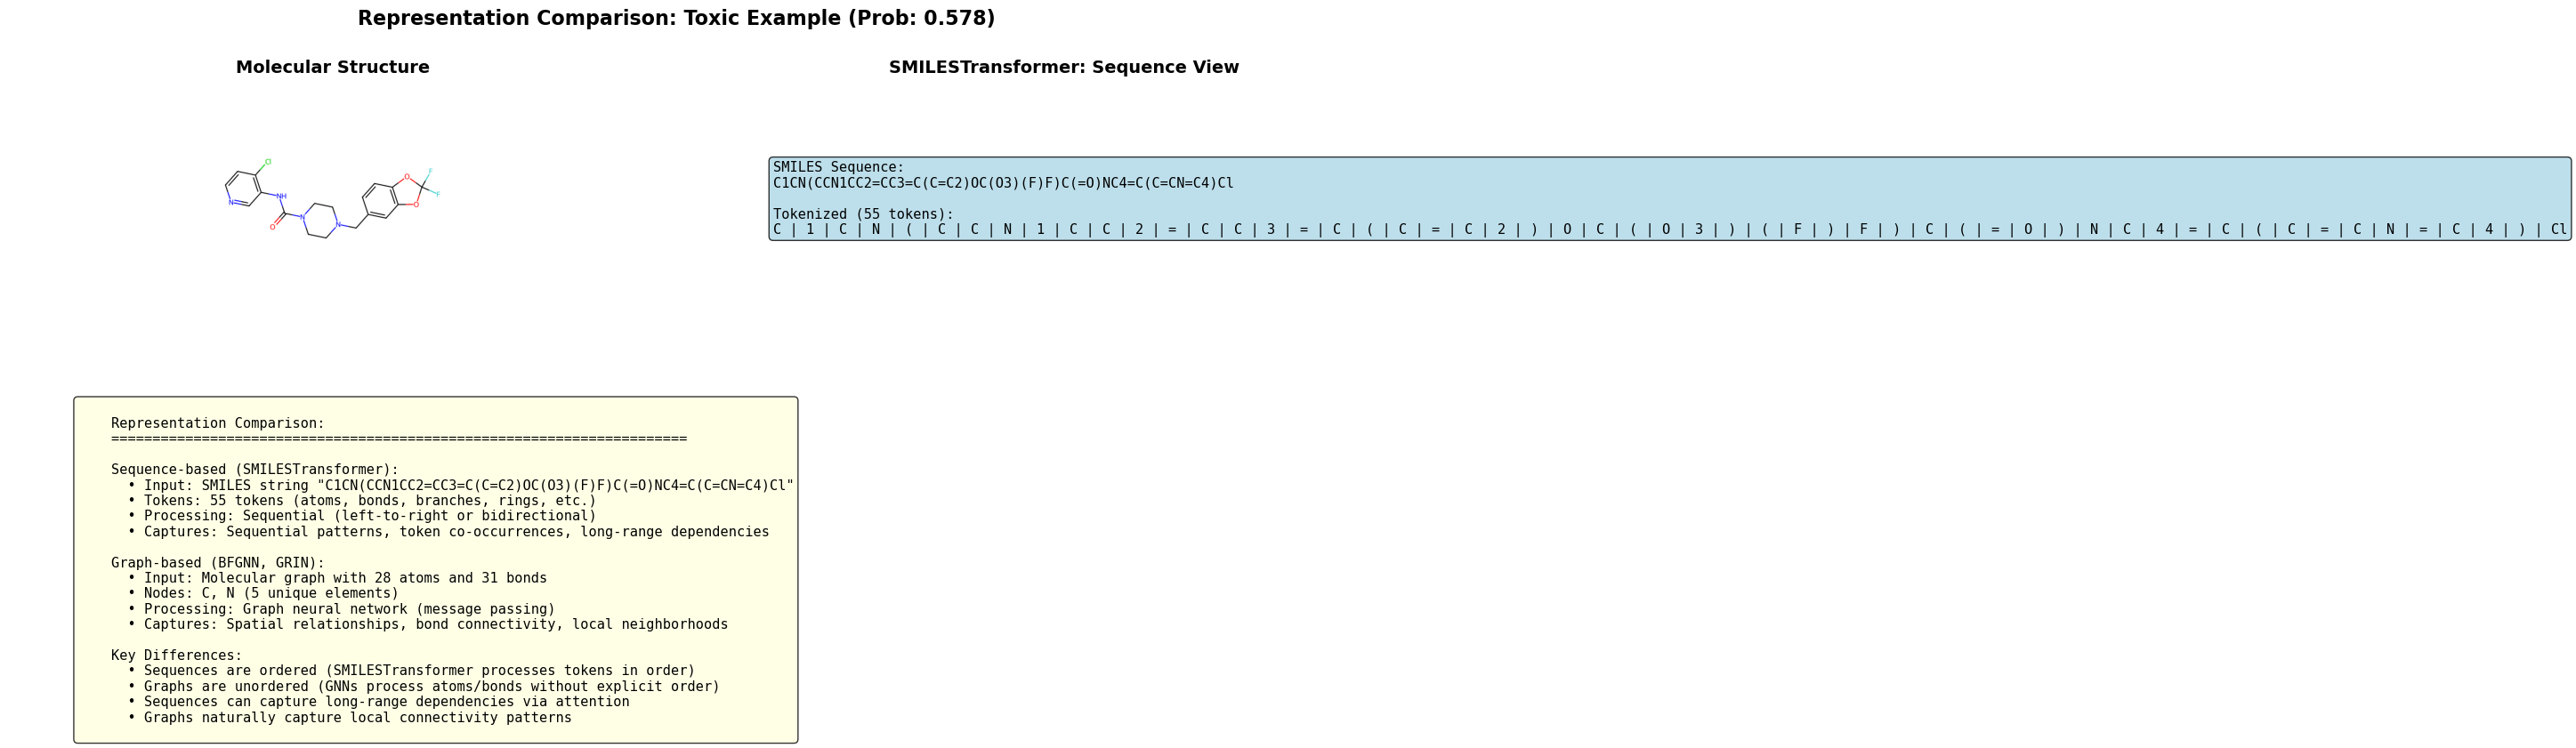

In [20]:
# Compare sequence-based vs graph-based representation
from rdkit.Chem import AllChem

def compare_representations(smiles, label=""):
    """Compare how different models represent the same molecule"""
    mol = smiles_to_mol(smiles)
    if mol is None:
        return
    
    fig = plt.figure(figsize=(20, 8))
    gs = fig.add_gridspec(2, 4, hspace=0.3, wspace=0.3)
    
    # Row 1: Molecular structure and SMILES sequence
    ax1 = fig.add_subplot(gs[0, 0:2])
    img = Draw.MolToImage(mol, size=(500, 500))
    ax1.imshow(img)
    ax1.axis('off')
    ax1.set_title('Molecular Structure', fontsize=14, fontweight='bold')
    
    ax2 = fig.add_subplot(gs[0, 2:])
    tokens = tokenize_smiles(smiles)
    token_display = ' | '.join(tokens)
    ax2.axis('off')
    ax2.text(0.05, 0.5, f'SMILES Sequence:\n{smiles}\n\nTokenized ({len(tokens)} tokens):\n{token_display}',
             fontsize=11, family='monospace',
             verticalalignment='center',
             bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    ax2.set_title('SMILESTransformer: Sequence View', fontsize=14, fontweight='bold')
    
    # Row 2: Graph representation comparison
    ax3 = fig.add_subplot(gs[1, :])
    ax3.axis('off')
    
    # Get graph information
    num_atoms = mol.GetNumAtoms()
    num_bonds = mol.GetNumBonds()
    
    # Get atom symbols
    atom_symbols = [mol.GetAtomWithIdx(i).GetSymbol() for i in range(num_atoms)]
    
    comparison_text = f"""
    Representation Comparison:
    {'='*70}
    
    Sequence-based (SMILESTransformer):
      • Input: SMILES string "{smiles}"
      • Tokens: {len(tokens)} tokens (atoms, bonds, branches, rings, etc.)
      • Processing: Sequential (left-to-right or bidirectional)
      • Captures: Sequential patterns, token co-occurrences, long-range dependencies
    
    Graph-based (BFGNN, GRIN):
      • Input: Molecular graph with {num_atoms} atoms and {num_bonds} bonds
      • Nodes: {', '.join(set(atom_symbols[:10]))}{'...' if len(set(atom_symbols)) > 10 else ''} ({len(set(atom_symbols))} unique elements)
      • Processing: Graph neural network (message passing)
      • Captures: Spatial relationships, bond connectivity, local neighborhoods
    
    Key Differences:
      • Sequences are ordered (SMILESTransformer processes tokens in order)
      • Graphs are unordered (GNNs process atoms/bonds without explicit order)
      • Sequences can capture long-range dependencies via attention
      • Graphs naturally capture local connectivity patterns
    """
    
    ax3.text(0.05, 0.95, comparison_text, fontsize=11, family='monospace',
             verticalalignment='top', transform=ax3.transAxes,
             bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.8))
    
    if label:
        fig.suptitle(f'Representation Comparison: {label}', fontsize=16, fontweight='bold', y=0.98)
    
    plt.tight_layout()
    return fig

if smilestransformer_model is not None:
    print("\n" + "=" * 80)
    print("Sequence vs Graph Representation Comparison")
    print("=" * 80)
    
    # Select one example for comparison
    example_smiles = None
    example_label = ""
    
    if correct_toxic_smilestransformer is not None and len(correct_toxic_smilestransformer) > 0:
        toxic_example = correct_toxic_smilestransformer.iloc[0]
        example_smiles = toxic_example['smiles']
        example_label = f"Toxic Example (Prob: {toxic_example['predicted_prob_smilestransformer']:.3f})"
    elif correct_nontoxic_smilestransformer is not None and len(correct_nontoxic_smilestransformer) > 0:
        nontoxic_example = correct_nontoxic_smilestransformer.iloc[0]
        example_smiles = nontoxic_example['smiles']
        example_label = f"Non-toxic Example (Prob: {nontoxic_example['predicted_prob_smilestransformer']:.3f})"
    
    if example_smiles:
        print(f"\nComparing representations for: {example_label}")
        fig = compare_representations(example_smiles, example_label)
        
        # Save figure
        figures_dir = project_root / "output" / "figures"
        figures_dir.mkdir(parents=True, exist_ok=True)
        plt.savefig(figures_dir / "04_smilestransformer_representation_comparison.png", dpi=300, bbox_inches='tight')
        print(f"✓ Representation comparison saved to: {figures_dir / '04_smilestransformer_representation_comparison.png'}")
        plt.show()
    else:
        print("⚠ No examples available for representation comparison")
else:
    print("⚠ SMILESTransformer model not available for representation comparison")


### Key Insights from SMILESTransformer Representation

1. **Sequence-Based Processing**: SMILESTransformer treats molecules as sequences of tokens, enabling:
   - Capture of sequential patterns and token co-occurrences
   - Long-range dependencies through attention mechanisms
   - Natural handling of SMILES notation as written

2. **Tokenization**: Molecules are broken down into discrete tokens representing:
   - Atoms (C, N, O, etc.)
   - Bonds (=, #, etc.)
   - Branches (parentheses)
   - Rings (numbers)
   - Special symbols

3. **Differences from Graph Models**:
   - **Order matters**: Sequences have explicit ordering (left-to-right or bidirectional)
   - **Long-range attention**: Can attend to tokens far apart in the sequence
   - **No explicit connectivity**: Doesn't explicitly model bonds like graphs do
   - **Token-level features**: Focuses on token embeddings rather than atom/bond features

4. **Complementary to Graph Models**:
   - Graph models excel at local connectivity patterns
   - Sequence models excel at long-range patterns and sequential dependencies
   - Both perspectives can provide valuable insights for molecular property prediction


## Summary

✓ Baseline MLP model explanations generated (gradient-based attribution)  
✓ BFGNN model explanations generated (perturbation-based attribution)  
✓ GRIN model explanations generated (perturbation-based attribution)  
✓ SMILESTransformer model explanations generated (perturbation-based attribution)  
✓ Visualizations created for toxic, non-toxic, and misclassified examples  
✓ Substructure analysis completed for all models  

**Key Insights:**
- Important substructures highlighted in red/yellow indicate features the model considers toxic
- Blue/green regions indicate features associated with non-toxicity
- Misclassified examples may reveal model limitations or data quality issues
- GNN models (BFGNN, GRIN) and sequence models (SMILESTransformer) use perturbation-based attribution (removing atoms and measuring prediction changes)

**Attribution Methods:**
- **Baseline MLP**: Fingerprint-based gradient attribution (computes gradients of output w.r.t. fingerprint bits, mapped to atoms)
- **BFGNN**: Graph-based perturbation attribution (systematically removes atoms and measures prediction changes)
- **GRIN**: Graph-based perturbation attribution (same method as BFGNN, but with GRIN's repetition-invariant architecture)
- **SMILESTransformer**: Sequence-based perturbation attribution (uses perturbation-based method on molecular graph representation for explainability, despite the model operating on SMILES sequences)

**Comparison:**
- Different models may highlight different molecular substructures as important
- Gradient-based methods (MLP) provide fast, differentiable attributions
- Perturbation-based methods (GNNs and transformers) are model-agnostic and interpretable but slower
- Comparing explanations across models reveals architectural biases and complementary insights
- Sequence-based models (SMILESTransformer) provide a different perspective compared to graph-based models

**Next Steps:**
- Proceed to `05_results_and_error_analysis.ipynb` for comprehensive results analysis including all four models
